In [1]:
import numpy as np
from mne_bids import BIDSPath
from mne import read_epochs

from ieeg.viz.ensemble import plot_vals_chanMap_video

%matplotlib inline

Qt5Agg backend not available, using default backend
Qt5Agg backend not available, using default backend


ImportError: cannot import name 'plot_vals_chanMap_video' from 'ieeg.viz.ensemble' (/hpc/group/coganlab/.conda/envs/ieeg_share/lib/python3.13/site-packages/ieeg/viz/ensemble.py)

In [ ]:
subject = "S82"
bidsRoot = "/hpc/home/zms14/cworkspace/BIDS_1.0_Lexical_µECoG/BIDS/derivatives/epoch(CAR)"
description="productionZscore"
suffix="highgamma"
ext=".fif"
task="lexical"
datatype="epoch(band)(power)"
kwargs = {"description": description, "suffix": suffix, "extension": ext, "task": task, "datatype": datatype}
tw = [-1, 1.5]

chan_map = np.array([
    [ np.nan,  80.,  78., 127., 115., 125.,  72.,  81.,  68.,  77.,  69.,
    82., 186., 184., 182., 191., 179., 189., 136., 145., 132., 177.,
    181.,  np.nan],
    [ np.nan,  52.,  29.,  27.,   2.,  59.,  36.,  34.,  51.,  74.,  67.,
    71., 188., 163., 185., 209., 221., 219., 194., 251., 228., 226.,
    198.,  np.nan],
    [ np.nan,  45.,  42.,  58.,  44.,  47.,  19.,  38.,  57., 121.,  65.,
    73., 190., 160., 138., 202., 217., 232., 207., 215., 210., 212.,
    214.,  np.nan],
    [ np.nan,  26.,  35.,  32.,   1.,  33.,  60.,  54.,  10., 117.,  89.,
    94., 192., 166., 144., 249., 205., 199., 229., 224., 193., 195.,
    233.,  np.nan],
    [ np.nan, 118.,  15.,  23.,  18.,  28.,  56.,  13.,  17., 113.,  83.,
    97., 165., 168., 142., 243., 246., 197., 231., 250., 236., 239.,
    141.,  np.nan],
    [ np.nan,  98., 116., 112., 123.,   3.,  64.,  25.,  14.,  49.,  87.,
    84., 170., 172., 206., 241., 230., 222., 227., 130., 159., 134.,
    157.,  np.nan],
    [ np.nan, 120.,  99.,  96., 100.,   9.,  41.,   6.,  61., 119.,  75.,
    86., 173., 178., 140., 200., 244., 218., 254., 155., 129., 131.,
    133.,  np.nan],
    [ np.nan, 103., 110., 111., 114.,  24.,  30.,  21.,  48.,  16.,  91.,
    79., 175., 164., 245., 223., 238., 256., 235., 139., 143., 149.,
    156.,  np.nan],
    [ np.nan, 109., 107., 105., 108.,   5.,  62.,  11.,  63.,  12.,  93.,
    85., 174., 162., 247., 196., 242., 201., 248., 151., 154., 152.,
    150.,  np.nan],
    [ np.nan, 128., 101., 106., 104.,   7.,  37.,  50.,   8.,  55.,  70.,
    92., 167., 180., 204., 253., 203., 225., 252., 147., 148., 161.,
    158.,  np.nan],
    [ np.nan, 126., 124., 122., 102.,  22.,  39.,  46.,  31.,  53.,  66.,
    90., 169., 187., 208., 240., 213., 220., 237., 153., 146., 135.,
    137.,  np.nan],
    [ np.nan,  np.nan,  np.nan,  np.nan,  np.nan,  20.,  43.,  40.,   4.,  76.,  95.,
    88., 171., 176., 183., 255., 211., 216., 234.,  np.nan,  np.nan,  np.nan,
    np.nan,  np.nan]
])[:,1:-1]

In [3]:
bidsPath = BIDSPath(
        root=bidsRoot,
        subject=subject,
        check=False,
        **kwargs
    )
dataPath = bidsPath.match()[0]

# extract data from epochs object
data = read_epochs(dataPath, preload=True)
t_data = data.times

# trim time window (takes default bound if None)
twEpoch = [t_data[0] if tw[0] is None else tw[0],
                    t_data[-1] if tw[1] is None else tw[1]]
data = data.crop(tmin=twEpoch[0], tmax=twEpoch[1])
features = data.get_data()

# Average across trials to get (time x channels) data matrix
features = np.mean(features, axis=0).T

Reading /hpc/home/zms14/cworkspace/BIDS_1.0_Lexical_µECoG/BIDS/derivatives/epoch(CAR)/sub-S81/epoch(band)(power)/sub-S81_task-lexical_desc-productionZscore_highgamma.fif ...


    Found the data of interest:
        t =   -1000.00 ...    1495.00 ms
        0 CTF compensation matrices available


/tmp/ipykernel_151693/929375734.py:10: RuntimeWarning: This filename (/hpc/home/zms14/cworkspace/BIDS_1.0_Lexical_µECoG/BIDS/derivatives/epoch(CAR)/sub-S81/epoch(band)(power)/sub-S81_task-lexical_desc-productionZscore_highgamma.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  data = read_epochs(dataPath, preload=True)


Not setting metadata
120 matching events found
No baseline correction applied
0 projection items activated


/tmp/ipykernel_151693/929375734.py:16: RuntimeWarning: tmax is not in time interval. tmax is set to <class 'mne.epochs.EpochsFIF'>.tmax (1.495 s)
  data = data.crop(tmin=twEpoch[0], tmax=twEpoch[1])


Video saved to: HG_timeseries.mp4


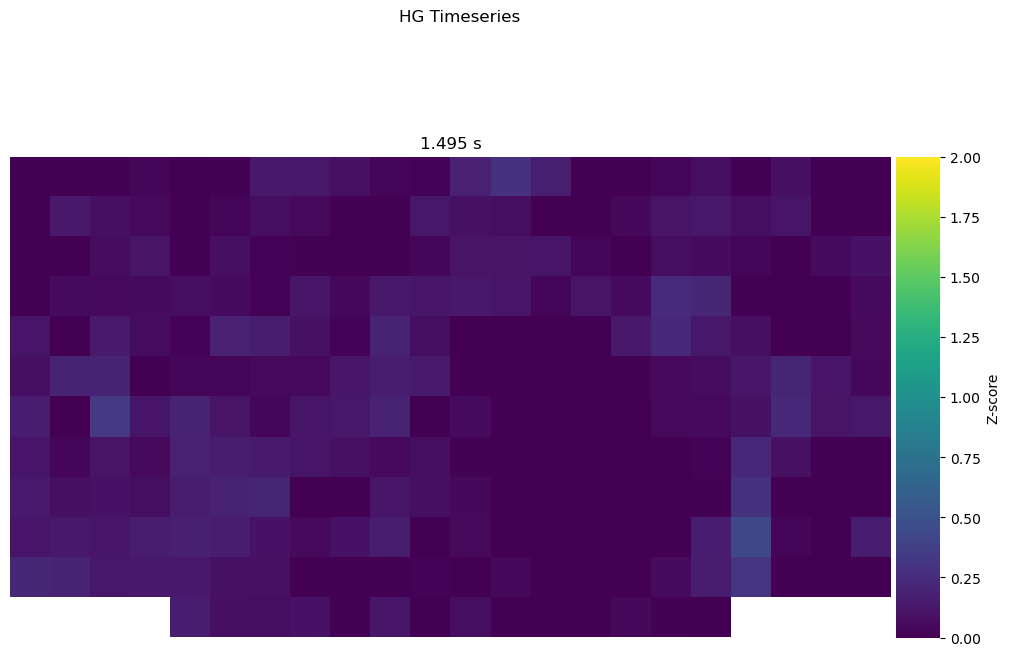

In [4]:
plot_vals_chanMap_video(features, chan_map, tw, "HG Timeseries", "Z-score", cbar_upper=2, cbar_lower=0, figsize=(12,8), fps=20, save_video=True, output_path='HG_timeseries.mp4')